# How To: Crop and Pad Images for Batch Consistency

Use `ImageCropper` to remove scanner borders and `ImagePadder` to make
images a uniform size for batch processing.

In [1]:
from phenotypic.data import load_yeast_plate_full
from phenotypic.correction import ImageCropper, ImagePadder

Original size: (4012, 6016, 3)


(<Figure size 640x480 with 1 Axes>, <Axes: >)

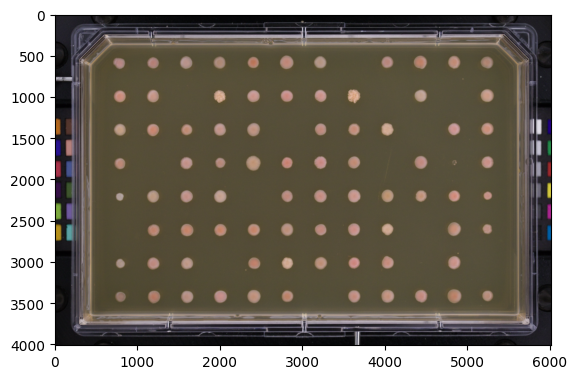

In [2]:
plate = load_yeast_plate_full()
print(f"Original size: {plate.shape}")
plate.show()

## Crop Scanner Borders

Remove unwanted borders by specifying pixels to trim from each edge.

Cropped size: (3112, 5116, 3)


(<Figure size 640x480 with 1 Axes>, <Axes: >)

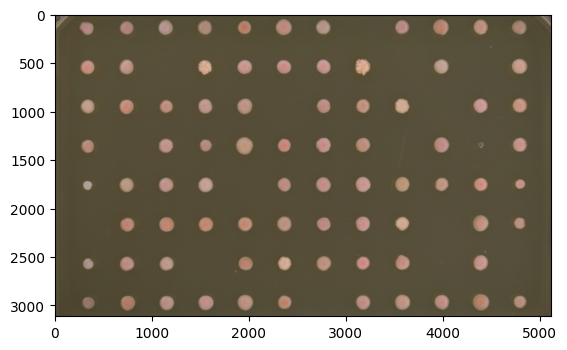

In [3]:
cropper = ImageCropper(top=450, bottom=450, left=450, right=450)
cropped = cropper.apply(plate)
print(f"Cropped size: {cropped.shape}")
cropped.show()

## Pad to Uniform Size

When batch-processing plates of different sizes, pad them to a consistent
dimension.

Padded size: (3152, 5156, 3)


(<Figure size 640x480 with 1 Axes>, <Axes: >)

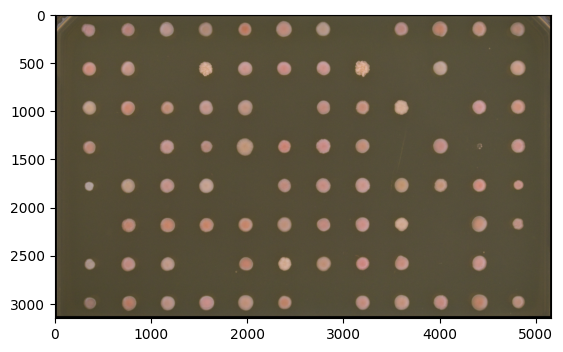

In [4]:
padder = ImagePadder(top=20, bottom=20, left=20, right=20, mode="constant",
                     constant_value=0)
padded = padder.apply(cropped)
print(f"Padded size: {padded.shape}")
padded.show()

Both operations can be included in an `ImagePipeline` for batch
processing. Place `ImageCropper` first, then `ImagePadder`, before
any detection steps.